# Choosing Performance Metrics for Clinical Prediction Models
**NC TraCS Technical Tutorials · Model Evaluation**

This notebook walks through one of the most common mistakes in clinical AI: **reporting accuracy as the primary measure of model quality**. We will show why accuracy alone is insufficient, what to use instead, and how to choose the right metric based on the clinical question your model is trying to answer.

We use a synthetic COVID-19 respiratory cohort built in the OMOP Common Data Model. The prediction task is **in-hospital mortality** — a classic imbalanced binary outcome. Every concept demonstrated here applies equally to readmission prediction, ICU transfer, adverse drug reactions, or any other clinical prediction problem.

### What you will learn
1. Why accuracy is misleading when outcomes are unequal in frequency
2. What sensitivity, specificity, AUC-ROC, and F1 actually measure — in plain terms
3. How to read an ROC curve and a Precision-Recall curve
4. How to choose a metric based on the clinical cost of being wrong
5. How to interpret a confusion matrix as a table of patient counts

### What you need beforehand
- Basic familiarity with Python (reading along is enough — you do not need to write code)
- No prior machine learning knowledge required

---
> **Note:** All data is synthetic. No real patient information is used in this notebook.

## Setup: Loading the Tools

The cell below loads the software libraries we will use. Think of this like turning on equipment before a procedure — nothing is happening with patient data yet. Run it once and move on.

The only library worth naming here is **scikit-learn** (`sklearn`). It is the standard toolkit for building and evaluating prediction models in clinical research. When a data science collaborator says they built a logistic regression or a random forest, this is almost certainly the library they used.

In [ ]:
# Software libraries — run this cell once before anything else
# (Uncomment the line below and run it first if any library is missing)
# !pip install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix,
    average_precision_score, roc_curve,
    precision_recall_curve, ConfusionMatrixDisplay
)

# Chart colors — consistent across all figures in this notebook
plt.rcParams.update({
    'figure.facecolor': '#F7F8FC',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'font.family': 'sans-serif'
})
TEAL   = '#0E7C86'
NAVY   = '#1A2744'
RED    = '#C94040'
AMBER  = '#E8A045'
GREEN  = '#3A8C5C'
PURPLE = '#5C3D99'

print('Ready.')

Ready.


## 1. Load the Dataset and Check the Outcome Distribution

The first thing to do with any clinical dataset is look at the **outcome distribution**: how many patients experienced the event we are trying to predict, versus how many did not.

This matters because prediction models learn from examples. If 90% of patients survived and 10% died, the model has nine times as many survival examples as death examples to learn from. That imbalance distorts many standard metrics — particularly accuracy — in ways that can hide a completely useless model.

We focus on **suspected COVID-19 visits only**, and our outcome is `deceased = Y` (in-hospital death).

In [ ]:
# Load the dataset — update the filename to match your file location
df = pd.read_csv('data.csv', parse_dates=['visit_start_date', 'visit_end_date',
                                               'measurement_Date'])

print(f'Total rows in dataset : {len(df):,}')
print(f'Unique patients        : {df["person_id"].nunique():,}')
print(f'\nVisit types:')
print(df['visit_type'].value_counts().to_string())

Total rows in dataset : 156,030
Unique patients        : 98,985

Visit types:
Outpatient Visit        134954
Inpatient Visit          21056
Emergency Room Visit        20


In [ ]:
# Keep only suspected COVID-19 visits
covid = df[df['observation_source'] == 'Suspected COVID-19'].copy()

# Convert outcome from text (Y/N) to number (1/0)
# Machine learning algorithms require numbers, not text labels
covid['deceased_bin'] = (covid['deceased'] == 'Y').astype(int)

print(f'COVID-19 visits : {len(covid):,}')
print(f'\nOutcome counts:')
print(covid['deceased_bin'].value_counts()
      .rename({0: 'Survived (0)', 1: 'Deceased (1)'})
      .to_string())
print(f'\nMortality rate  : {covid["deceased_bin"].mean():.1%}')
print(f'Survival rate   : {1 - covid["deceased_bin"].mean():.1%}')
print()
print('--- What this means for accuracy ---')
print(f'A model predicting survival for every patient scores {1 - covid["deceased_bin"].mean():.1%} accuracy.')
print('That is the floor accuracy has to beat just to be non-trivial.')

COVID-19 visits : 73,304

Outcome counts:
Survived (0)    57241
Deceased (1)    16063

Mortality rate  : 21.9%
Survival rate   : 78.1%

--- What this means for accuracy ---
A model predicting survival for every patient scores 78.1% accuracy.
That is the floor accuracy has to beat just to be non-trivial.


### Figure 1: How unequal are the two outcome groups?

The left panel shows raw counts. The right panel breaks down mortality by visit type — which matters because inpatient and outpatient patients are very different populations, and a model evaluated on both mixed together may not generalize to either one alone.

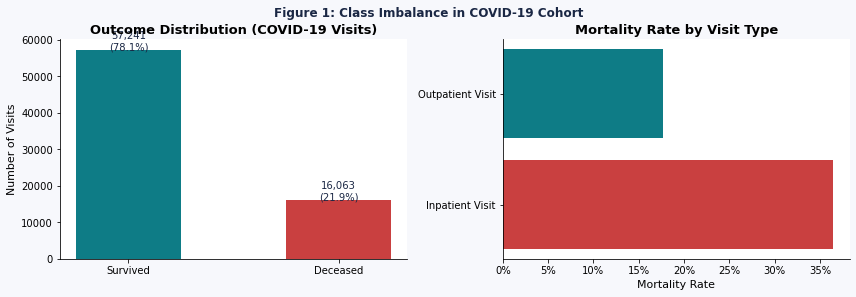

Inpatient mortality is substantially higher than outpatient.
A model evaluated on the mixed cohort may not generalize to inpatients alone.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left panel: overall outcome split
counts = covid['deceased_bin'].value_counts()
bars = axes[0].bar(['Survived', 'Deceased'],
                   counts.values,
                   color=[TEAL, RED], width=0.5, edgecolor='none')
axes[0].set_title('Outcome Distribution (COVID-19 Visits)', fontweight='bold')
axes[0].set_ylabel('Number of Visits')
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{count:,}\n({count/len(covid):.1%})',
                 ha='center', fontsize=10, color=NAVY)

# Right panel: mortality rate by visit type
visit_mort = covid.groupby('visit_type')['deceased_bin'].mean().sort_values(ascending=False)
colors = [RED if 'Inpatient' in v else TEAL for v in visit_mort.index]
axes[1].barh(visit_mort.index, visit_mort.values, color=colors, edgecolor='none')
axes[1].set_xlabel('Mortality Rate')
axes[1].set_title('Mortality Rate by Visit Type', fontweight='bold')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.suptitle('Figure 1: Class Imbalance in COVID-19 Cohort',
             y=1.02, fontsize=12, color=NAVY, fontweight='bold')
plt.show()

print('Inpatient mortality is substantially higher than outpatient.')
print('A model evaluated on the mixed cohort may not generalize to inpatients alone.')

## 2. Preparing the Predictor Variables

Machine learning models require **numbers**. Clinical data arrives as text, dates, and codes. This step converts the raw data into a structured table where every column is a numeric predictor — essentially building the model's input spreadsheet.

Each row is one visit. Each column answers a yes/no clinical question:
- Was this an inpatient visit? (1 = yes, 0 = no)
- Was the patient over 65? (1 = yes, 0 = no)
- Did the condition list include pneumonia? (1 = yes, 0 = no)
- And so on.

Continuous values like age, heart rate, and blood pressure are used as-is.

> **Note on missing data:** Vital signs are only recorded for COVID-19 visits in this dataset. Their absence for other visit types is not accidental — it reflects how the data was collected. We note this because it means the missingness pattern carries clinical information.

In [ ]:
covid = covid.copy()

# Convert each clinical characteristic into a yes/no number
covid['is_inpatient']  = (covid['visit_type'] == 'Inpatient Visit').astype(int)
covid['is_female']     = (covid['gender_source_value'] == 'F').astype(int)
covid['is_elderly']    = (covid['age_at_visit_years'] > 65).astype(int)
covid['is_pediatric']  = (covid['age_at_visit_years'] < 18).astype(int)
covid['has_pneumonia'] = covid['condition'].str.contains('Pneumonia', na=False).astype(int)
covid['has_dyspnea']   = covid['condition'].str.contains('Dyspnea', na=False).astype(int)
covid['has_resp_dist'] = covid['condition'].str.contains('Respiratory distress', na=False).astype(int)
covid['low_spo2']      = (covid['oxygen_saturation_percent'] < 90).astype(int)  # hypoxemia
covid['high_temp']     = (covid['body_temperature_c'] > 38.5).astype(int)       # fever
covid['n_conditions']  = covid['condition'].str.count(':').fillna(0) + 1         # total conditions listed

FEATURES = [
    'age_at_visit_years', 'is_inpatient', 'is_female', 'is_elderly',
    'is_pediatric', 'has_pneumonia', 'has_dyspnea', 'has_resp_dist',
    'n_conditions', 'body_temperature_c', 'systolic', 'diastolic',
    'heart_rate_bpm', 'oxygen_saturation_percent', 'respiratory_rate_per_minute',
    'low_spo2', 'high_temp', 'bmi'
]

X = covid[FEATURES]        # predictor variables — input to the model
y = covid['deceased_bin']  # outcome variable — what the model is trying to predict

# Show which variables have missing data
missing_pct = X.isnull().mean().sort_values(ascending=False)
print('Missing data by variable (variables with no missing data are omitted):')
print(missing_pct[missing_pct > 0].apply(lambda x: f'{x:.1%}').to_string())

Missing data by variable (variables with no missing data are omitted):
bmi                            99.9%
oxygen_saturation_percent       0.0%
body_temperature_c              0.0%
respiratory_rate_per_minute     0.0%
heart_rate_bpm                  0.0%
diastolic                       0.0%
systolic                        0.0%


## 3. Training Set vs. Test Set

We divide the data into two groups before building any model:

- **Training set (80%):** The visits the model learns from.
- **Test set (20%):** Held back and never shown to the model during training. We use it at the end to simulate how the model would perform on new patients it has never seen.

Two additional steps follow:
- **Filling in missing values:** We replace blanks with the median value of each variable. Most algorithms cannot work with missing data.
- **Rescaling variables:** We re-express all variables on the same numerical range. Without this, a variable like systolic blood pressure (typically 100-180) could numerically dominate a variable like patient age (typically 20-80) for no clinical reason.

In [ ]:
# Split into training (80%) and test (20%) sets
# stratify=y ensures both sets have the same proportion of deaths
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fill missing values with the median, then rescale all variables
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

X_train_proc = scaler.fit_transform(imputer.fit_transform(X_train))
X_test_proc  = scaler.transform(imputer.transform(X_test))

print(f'Training set : {len(X_train):,} visits  |  Mortality: {y_train.mean():.1%}')
print(f'Test set     : {len(X_test):,} visits   |  Mortality: {y_test.mean():.1%}')
print()
print('The mortality rate is identical in both sets.')
print('This is by design (stratify=y) — it ensures the test is a fair evaluation.')

Training set : 58,643 visits  |  Mortality: 21.9%
Test set     : 14,661 visits   |  Mortality: 21.9%

The mortality rate is identical in both sets.
This is by design (stratify=y) — it ensures the test is a fair evaluation.


## 4. The Accuracy Paradox

We now demonstrate the core problem with using accuracy as the main metric for clinical prediction.

We will build the **worst possible model**: one that predicts survival for every single patient, with no clinical information at all. Then we measure its accuracy.

**What 97% accuracy actually means:** out of 100 patients, the model correctly classified 97. Impressive on the surface. But look at what happened to the 3 it got wrong — they were all deaths that were predicted as survivals. The model caught zero deaths. Sensitivity = 0%.

Accuracy measures how often the model is right overall. It does not distinguish between being right about the common outcome (survival) and being right about the rare but critical outcome (death). In an imbalanced dataset, a model can be highly accurate while being completely useless for the clinical task.

In [ ]:
# Build the trivial model: predict survival for every patient
y_pred_trivial = np.zeros(len(y_test), dtype=int)  # 0 = survived, for every patient
y_prob_trivial = np.zeros(len(y_test))              # predicted probability of death = 0 for everyone

acc_trivial = accuracy_score(y_test, y_pred_trivial)
auc_trivial = roc_auc_score(y_test, y_prob_trivial)
f1_trivial  = f1_score(y_test, y_pred_trivial, zero_division=0)

print('=== TRIVIAL MODEL: always predict survival ===')
print(f'  Accuracy    : {acc_trivial:.1%}  <- sounds good')
print(f'  Sensitivity : 0.0%        <- caught ZERO deaths')
print(f'  AUC-ROC     : {auc_trivial:.3f}     <- same as a coin flip')
print(f'  F1 Score    : {f1_trivial:.3f}     <- zero, because no deaths were flagged')
print()
print('The accuracy is not a property of the model.')
print(f'It equals the survival rate in the test set ({1-y_test.mean():.1%}).')
print('A model that correctly classifies all survivors achieves this')
print('while missing every single death.')

=== TRIVIAL MODEL: always predict survival ===
  Accuracy    : 78.1%  <- sounds good
  Sensitivity : 0.0%        <- caught ZERO deaths
  AUC-ROC     : 0.500     <- same as a coin flip
  F1 Score    : 0.000     <- zero, because no deaths were flagged

The accuracy is not a property of the model.
It equals the survival rate in the test set (78.1%).
A model that correctly classifies all survivors achieves this
while missing every single death.


### Comparing against a real model

Now we train a **logistic regression** — the same statistical framework behind many published clinical prediction rules (Wells score, HEART score, CHADS2-VASc, etc.).

The `class_weight='balanced'` parameter tells the algorithm to pay extra attention to deaths during training, compensating for the fact that deaths are less common. Without this, the model is tempted to predict survival most of the time because that is usually correct — making it behave like the trivial model above.

We compute **seven metrics** side by side. Each answers a different clinical question:

| Metric | Clinical question |
|--------|------------------|
| Accuracy | How often was the model right overall? |
| AUC-ROC | Across all thresholds, how well does it separate deaths from survivals? |
| Sensitivity | Of the patients who died, what fraction did the model flag as high risk? |
| Specificity | Of the patients who survived, what fraction did the model correctly leave unflagged? |
| Precision (PPV) | Of the patients flagged as high risk, what fraction actually died? |
| F1 | Combined score balancing sensitivity and precision |
| PR-AUC | Like AUC-ROC, but focused entirely on the minority class (deaths) |

In [ ]:
lr_balanced = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_balanced.fit(X_train_proc, y_train)

y_pred_lr = lr_balanced.predict(X_test_proc)          # predicted class: 0 or 1
y_prob_lr = lr_balanced.predict_proba(X_test_proc)[:, 1]  # predicted probability of death

def evaluate_model(y_true, y_pred, y_prob, model_name):
    from sklearn.metrics import recall_score, precision_score
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    metrics = {
        'Accuracy'   : accuracy_score(y_true, y_pred),
        'AUC-ROC'    : roc_auc_score(y_true, y_prob),
        'PR-AUC'     : average_precision_score(y_true, y_prob),
        'Sensitivity': recall_score(y_true, y_pred, zero_division=0),
        'Specificity': tn / (tn + fp),
        'Precision'  : precision_score(y_true, y_pred, zero_division=0),
        'F1 Score'   : f1_score(y_true, y_pred, zero_division=0),
    }
    print(f'\n=== {model_name} ===')
    notes = {
        'Sensitivity': '  <- prioritize this for mortality prediction',
        'AUC-ROC'    : '  <- best single summary metric for imbalanced data',
    }
    for name, val in metrics.items():
        print(f'  {name:<13}: {val:.3f}{notes.get(name, "")}')
    return metrics

metrics_lr = evaluate_model(y_test, y_pred_lr, y_prob_lr, 'Logistic Regression (class-balanced)')

print()
print('--- Compare to the trivial model ---')
print(f'  Trivial accuracy    : {acc_trivial:.1%}  |  Logistic accuracy    : {metrics_lr["Accuracy"]:.1%}')
print(f'  Trivial sensitivity : 0.0%        |  Logistic sensitivity : {metrics_lr["Sensitivity"]:.1%}')
print()
print('The real model has LOWER accuracy than the trivial model.')
print('This is expected and correct: it now catches deaths, which means it will')
print('sometimes incorrectly flag survivors. That is the right clinical tradeoff.')


=== Logistic Regression (class-balanced) ===
  Accuracy     : 0.634
  AUC-ROC      : 0.719  <- best single summary metric for imbalanced data
  PR-AUC       : 0.379
  Sensitivity  : 0.703  <- prioritize this for mortality prediction
  Specificity  : 0.614
  Precision    : 0.338
  F1 Score     : 0.457

--- Compare to the trivial model ---
  Trivial accuracy    : 78.1%  |  Logistic accuracy    : 63.4%
  Trivial sensitivity : 0.0%        |  Logistic sensitivity : 70.3%

The real model has LOWER accuracy than the trivial model.
This is expected and correct: it now catches deaths, which means it will
sometimes incorrectly flag survivors. That is the right clinical tradeoff.


## 5. ROC and Precision-Recall Curves

The metrics above were computed at a single decision threshold: flag any patient with a predicted death probability of 50% or higher. But we can raise or lower that cutoff.

- **Lower the threshold** → flags more patients as high risk → catches more deaths, but also more false alarms
- **Raise the threshold** → more conservative → fewer false alarms, but misses more deaths

The **ROC curve** shows how sensitivity and false alarm rate trade off as the threshold moves across its full range. The **area under this curve (AUC)** summarizes the model's overall ability to separate deaths from survivals. AUC = 0.5 means the model performs no better than random guessing. AUC = 1.0 means perfect separation.

The **Precision-Recall curve** is more useful when deaths are the minority. It focuses entirely on the model's performance on the minority class, making it harder for a model to look good by being good at predicting the majority.

We also train a **Random Forest** for comparison — a model that builds many decision trees and averages their predictions.

In [ ]:
# Train random forest for comparison
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train_proc, y_train)
y_pred_rf = rf.predict(X_test_proc)
y_prob_rf  = rf.predict_proba(X_test_proc)[:, 1]

metrics_rf = evaluate_model(y_test, y_pred_rf, y_prob_rf, 'Random Forest (class-balanced)')


=== Random Forest (class-balanced) ===
  Accuracy     : 0.778
  AUC-ROC      : 0.700  <- best single summary metric for imbalanced data
  PR-AUC       : 0.357
  Sensitivity  : 0.042  <- prioritize this for mortality prediction
  Specificity  : 0.984
  Precision    : 0.429
  F1 Score     : 0.076


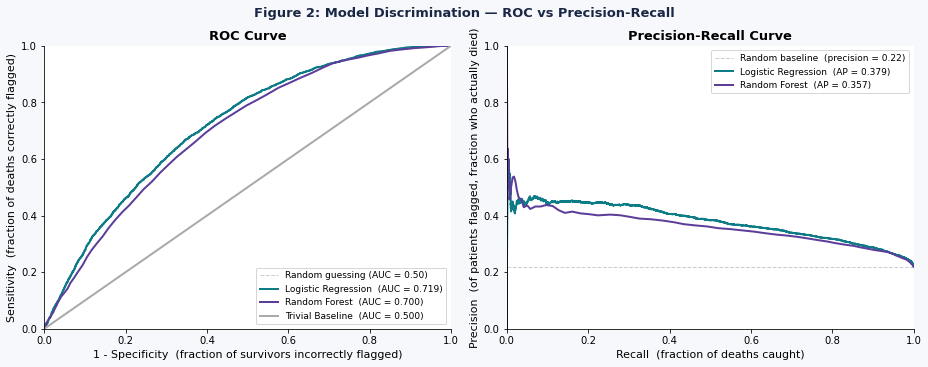

How to read these:
  ROC:  higher and closer to top-left corner = better. AUC > 0.75 is acceptable; > 0.85 is strong.
  PR:   higher and further right = better. A curve near the dashed line adds little value.
  Always show both curves when presenting a clinical prediction model.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models = [
    ('Logistic Regression', y_prob_lr,      TEAL),
    ('Random Forest',       y_prob_rf,      PURPLE),
    ('Trivial Baseline',    y_prob_trivial, '#AAAAAA'),
]

# ── LEFT: ROC Curve ──────────────────────────────────────────
# X-axis: false positive rate (fraction of survivors incorrectly flagged)
# Y-axis: true positive rate = sensitivity (fraction of deaths correctly flagged)
# Dashed diagonal = random guessing. A useful model curves toward the top-left.
ax = axes[0]
ax.plot([0,1],[0,1],'--', color='#CCCCCC', lw=1, label='Random guessing (AUC = 0.50)')
for name, probs, color in models:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC = {auc:.3f})')
ax.set_xlabel('1 - Specificity  (fraction of survivors incorrectly flagged)')
ax.set_ylabel('Sensitivity  (fraction of deaths correctly flagged)')
ax.set_title('ROC Curve', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0,1]); ax.set_ylim([0,1])

# ── RIGHT: Precision-Recall Curve ────────────────────────────
# X-axis: recall = sensitivity (fraction of deaths caught)
# Y-axis: precision = PPV (of patients flagged, fraction who actually died)
# Dashed line = random baseline (equal to the mortality rate in the test set)
ax = axes[1]
baseline_pr = y_test.mean()
ax.axhline(baseline_pr, linestyle='--', color='#CCCCCC', lw=1,
           label=f'Random baseline  (precision = {baseline_pr:.2f})')
for name, probs, color in models[:2]:
    prec, rec, _ = precision_recall_curve(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)
    ax.plot(rec, prec, color=color, lw=2, label=f'{name}  (AP = {pr_auc:.3f})')
ax.set_xlabel('Recall  (fraction of deaths caught)')
ax.set_ylabel('Precision  (of patients flagged, fraction who actually died)')
ax.set_title('Precision-Recall Curve', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim([0,1]); ax.set_ylim([0,1])

plt.suptitle('Figure 2: Model Discrimination — ROC vs Precision-Recall',
             fontsize=13, fontweight='bold', color=NAVY, y=1.01)
plt.tight_layout()
plt.show()

print('How to read these:')
print('  ROC:  higher and closer to top-left corner = better. AUC > 0.75 is acceptable; > 0.85 is strong.')
print('  PR:   higher and further right = better. A curve near the dashed line adds little value.')
print('  Always show both curves when presenting a clinical prediction model.')

## 6. The Confusion Matrix: Results as Patient Counts

The ROC curve summarizes performance across all thresholds. The **confusion matrix** shows what happens at a single chosen threshold — and expresses it as **counts of patients**, which is how clinicians think.

Four possible outcomes for each patient:

| | Model predicted: Death | Model predicted: Survival |
|---|---|---|
| **Patient actually died** | True Positive — correctly flagged | False Negative — missed |
| **Patient actually survived** | False Positive — false alarm | True Negative — correctly cleared |

In clinical terms:
- **False Negatives** are the most dangerous error in mortality prediction — a patient who needed escalation but was not flagged
- **False Positives** waste resources — a patient who did not need escalation but received it anyway

The threshold you choose determines the balance between these two error types. That choice is clinical, not statistical.

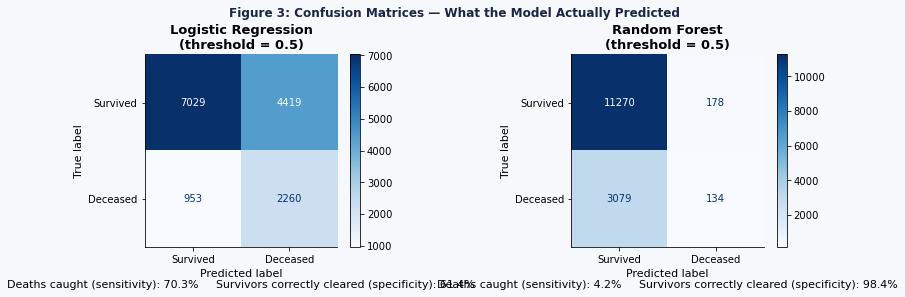

Plain-language summary:

  Logistic Regression:
    Caught    : 2260 of 3213 deaths  (70.3% sensitivity)
    Missed    : 953 deaths  (predicted survival, patient died)
    False alarms: 4419 survivors flagged as high risk

  Random Forest:
    Caught    : 134 of 3213 deaths  (4.2% sensitivity)
    Missed    : 3079 deaths  (predicted survival, patient died)
    False alarms: 178 survivors flagged as high risk


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, y_pred) in zip(axes, [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest',       y_pred_rf)
]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Survived', 'Deceased'])
    disp.plot(ax=ax, cmap='Blues')
    ax.set_title(f'{name}\n(threshold = 0.5)', fontweight='bold')

    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    ax.set_xlabel(
        f'Predicted label\n'
        f'Deaths caught (sensitivity): {sens:.1%}     '
        f'Survivors correctly cleared (specificity): {spec:.1%}'
    )

plt.suptitle('Figure 3: Confusion Matrices — What the Model Actually Predicted',
             fontsize=12, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.show()

# Print as plain patient counts
print('Plain-language summary:')
for name, y_pred in [('Logistic Regression', y_pred_lr), ('Random Forest', y_pred_rf)]:
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    total_deaths = tp + fn
    print(f'\n  {name}:')
    print(f'    Caught    : {tp} of {total_deaths} deaths  ({tp/total_deaths:.1%} sensitivity)')
    print(f'    Missed    : {fn} deaths  (predicted survival, patient died)')
    print(f'    False alarms: {fp} survivors flagged as high risk')

### What happens when we move the threshold?

The confusion matrix above used a threshold of 0.5 — the model flags a patient when its estimated probability of death reaches 50%. But we can lower that to flag anyone at 20%, or raise it to only flag patients at 80% predicted risk.

The chart below shows how each metric changes across the full range of possible thresholds. **Notice that accuracy barely moves.** This is precisely why accuracy cannot guide threshold selection in clinical practice.

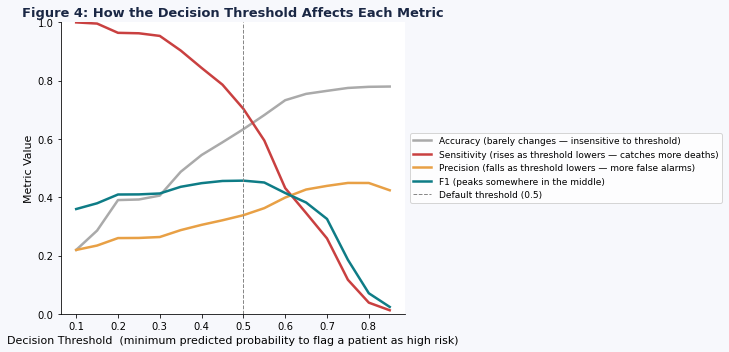

For mortality prediction where missing a death is the greater risk:
consider lowering the threshold to increase sensitivity,
accepting more false alarms in exchange for fewer missed deaths.


In [ ]:
from sklearn.metrics import recall_score, precision_score

thresholds = np.arange(0.1, 0.9, 0.05)
results = []
for t in thresholds:
    y_pred_t = (y_prob_lr >= t).astype(int)
    results.append({
        'Threshold'  : t,
        'Accuracy'   : accuracy_score(y_test, y_pred_t),
        'Sensitivity': recall_score(y_test, y_pred_t, zero_division=0),
        'Precision'  : precision_score(y_test, y_pred_t, zero_division=0),
        'F1'         : f1_score(y_test, y_pred_t, zero_division=0),
    })

thresh_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 5))
for col, color, note in [
    ('Accuracy',    '#AAAAAA', '(barely changes — insensitive to threshold)'),
    ('Sensitivity', RED,       '(rises as threshold lowers — catches more deaths)'),
    ('Precision',   AMBER,     '(falls as threshold lowers — more false alarms)'),
    ('F1',          TEAL,      '(peaks somewhere in the middle)'),
]:
    ax.plot(thresh_df['Threshold'], thresh_df[col], color=color, lw=2.5,
            label=f'{col} {note}')

ax.axvline(0.5, color='#888888', linestyle='--', lw=1,
           label='Default threshold (0.5)')
ax.set_xlabel('Decision Threshold  (minimum predicted probability to flag a patient as high risk)')
ax.set_ylabel('Metric Value')
ax.set_title('Figure 4: How the Decision Threshold Affects Each Metric',
             fontweight='bold', color=NAVY)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()

print('For mortality prediction where missing a death is the greater risk:')
print('consider lowering the threshold to increase sensitivity,')
print('accepting more false alarms in exchange for fewer missed deaths.')

## 7. Choosing the Right Metric for Your Clinical Task

There is no single best metric. The right choice depends on **what the model is for** and **what the cost of each error type is** in your specific clinical setting.

The **F-beta score** lets you express this priority as a number. It is a generalization of F1:
- **Beta = 1:** Equal importance to catching cases and avoiding false alarms (standard F1)
- **Beta > 1:** Catching cases matters more — use for mortality, ICU transfer, serious adverse events
- **Beta < 1:** Avoiding false alarms matters more — use when interventions are expensive or carry their own risk

The same model receives very different scores depending on beta. **Choosing a metric is a clinical decision, not a statistical one.** It encodes your values about what kinds of errors are acceptable.

In [ ]:
from sklearn.metrics import fbeta_score

print('F-beta score: same model, different clinical priorities\n')
print(f'  {"Beta":<6}  {"Score":<8}  Clinical use case')
print('  ' + '-' * 60)

betas_and_tasks = [
    (0.5, 'Expensive or invasive intervention — minimize false alarms'),
    (1.0, 'Balanced (standard F1 — equal weight to both error types)'),
    (2.0, 'Mortality prediction — prioritize catching deaths'),
    (3.0, 'ICU triage — missing a death is unacceptable'),
]
for beta, task in betas_and_tasks:
    score = fbeta_score(y_test, y_pred_lr, beta=beta, zero_division=0)
    print(f'  {beta:<6}  {score:.3f}     {task}')

print()
print('The score changes substantially depending on beta.')
print('This reflects the model trading sensitivity against precision.')
print('Choose beta to match the clinical cost of each error type in your setting.')

F-beta score: same model, different clinical priorities

  Beta    Score     Clinical use case
  ------------------------------------------------------------
  0.5     0.378     Expensive or invasive intervention — minimize false alarms
  1.0     0.457     Balanced (standard F1 — equal weight to both error types)
  2.0     0.579     Mortality prediction — prioritize catching deaths
  3.0     0.635     ICU triage — missing a death is unacceptable

The score changes substantially depending on beta.
This reflects the model trading sensitivity against precision.
Choose beta to match the clinical cost of each error type in your setting.


### The full picture: trivial model vs. real models

The table below is the clearest demonstration of the accuracy paradox. Look at the Accuracy column first — then look at everything else.

In [ ]:
from sklearn.metrics import recall_score, precision_score

summary = pd.DataFrame({
    'Model': ['Trivial (always predict survival)', 'Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_trivial),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, y_prob_trivial),
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
    ],
    'Sensitivity': [
        recall_score(y_test, y_pred_trivial, zero_division=0),
        recall_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
    ],
    'F1': [
        f1_score(y_test, y_pred_trivial, zero_division=0),
        f1_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0),
    ],
})

print(summary.set_index('Model').round(3).to_string())
print()
print('What this table shows:')
print('  Accuracy    : competitive across all three, including the useless trivial model')
print('  AUC-ROC     : trivial model = 0.5 (random), real models substantially higher')
print('  Sensitivity : trivial model = 0 (caught no deaths), real models > 0')
print('  F1          : trivial model = 0, real models > 0')
print()
print('If someone reports only accuracy for a clinical prediction model,')
print('ask for AUC, sensitivity, and F1 before drawing any conclusions.')

                                   Accuracy  AUC-ROC  Sensitivity     F1
Model                                                                   
Trivial (always predict survival)     0.781    0.500        0.000  0.000
Logistic Regression                   0.634    0.719        0.703  0.457
Random Forest                         0.778    0.700        0.042  0.076

What this table shows:
  Accuracy    : competitive across all three, including the useless trivial model
  AUC-ROC     : trivial model = 0.5 (random), real models substantially higher
  Sensitivity : trivial model = 0 (caught no deaths), real models > 0
  F1          : trivial model = 0, real models > 0

If someone reports only accuracy for a clinical prediction model,
ask for AUC, sensitivity, and F1 before drawing any conclusions.


## 8. Which Variables Did the Model Use?

A model that performs well on the right metrics still needs to be **clinically plausible**. Feature importance tells us which patient variables the model relied on most when making predictions.

This matters for two reasons:
1. **Sanity check:** If the model heavily uses a variable that should have no relationship to mortality, something may be wrong with the data or the model
2. **Actionability:** Variables that are both important and *modifiable* point toward potential interventions

> **Important:** Feature importance shows what the model *used*, not what *caused* the outcome. A variable can be statistically important because it is a genuine risk factor, or because it is a proxy for something else entirely. Always interpret these results alongside clinical judgment.

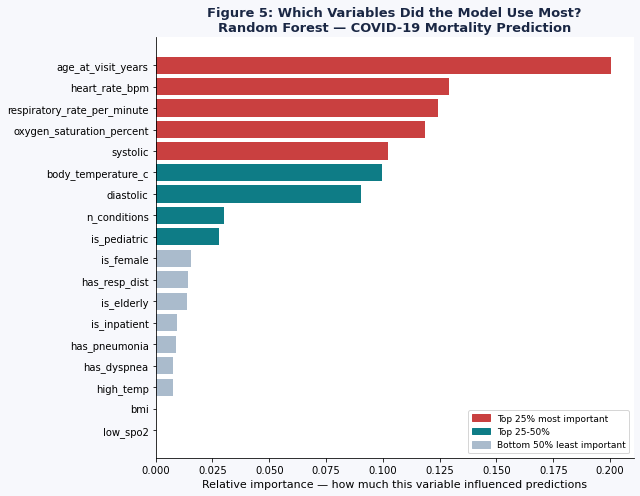

Top 5 most important variables:
  age_at_visit_years                 : 0.2003
  heart_rate_bpm                     : 0.1292
  respiratory_rate_per_minute        : 0.1241
  oxygen_saturation_percent          : 0.1187
  systolic                           : 0.1023

Clinical sense check: are these the variables you would expect to predict mortality?
If unexpected variables dominate, investigate for data quality issues.


In [ ]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors_imp = [RED  if imp > importances.quantile(0.75) else
              TEAL if imp > importances.quantile(0.5)  else
              '#AABBCC' for imp in importances.values]
ax.barh(importances.index, importances.values, color=colors_imp, edgecolor='none')

# Relabel axis in plain English
ax.set_xlabel('Relative importance — how much this variable influenced predictions')
ax.set_title('Figure 5: Which Variables Did the Model Use Most?\n'
             'Random Forest — COVID-19 Mortality Prediction',
             fontweight='bold', color=NAVY)

legend_elements = [
    mpatches.Patch(color=RED,       label='Top 25% most important'),
    mpatches.Patch(color=TEAL,      label='Top 25-50%'),
    mpatches.Patch(color='#AABBCC', label='Bottom 50% least important'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

print('Top 5 most important variables:')
for feat, imp in importances.tail(5).sort_values(ascending=False).items():
    print(f'  {feat:<35}: {imp:.4f}')
print()
print('Clinical sense check: are these the variables you would expect to predict mortality?')
print('If unexpected variables dominate, investigate for data quality issues.')

## 9. Summary: Which Metric to Use

Use this table as a reference when evaluating any clinical prediction model.

| Your situation | Recommended metric | Do not rely on |
|----------------|-------------------|----------------|
| Outcomes roughly equally common | Accuracy, F1 | — |
| Outcomes unequal (e.g. 1 in 5 to 1 in 20) | **AUC-ROC**, F1, Sensitivity | Accuracy alone |
| Outcome very rare (less than 1%) | **PR-AUC**, F1 | AUC-ROC alone |
| Missing a case is serious (mortality, serious adverse events) | **Sensitivity**, F-beta (beta > 1) | Precision alone |
| False alarms are costly (invasive procedures, scarce resources) | **Precision**, Specificity | Recall alone |
| Model outputs a probability used in clinical decisions | **Brier Score + calibration curve** | Any threshold metric alone |

### The single most important question

> *Of the patients who actually experienced the outcome, what fraction did the model correctly identify?*

That is **sensitivity**. It is the metric most directly connected to whether the model can do its clinical job.

---
### References
- Saito T & Rehmsmeier M (2015). *The Precision-Recall Plot Is More Informative than the ROC Plot When Evaluating Binary Classifiers on Imbalanced Datasets.* PLOS ONE.
- Steyerberg EW et al. (2010). *Assessing the Performance of Prediction Models.* Epidemiology.
- NC TraCS Technical Tutorials: https://nctracs-support.github.io/site/tutorials.html